In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder


df = pd.read_csv('../data/stunting_wasting_dataset.csv')
df.head()

,Jenis Kelamin,Umur (bulan),Tinggi Badan (cm),Berat Badan (kg),Stunting,Wasting
0,Laki-laki,19,91.6,13.3,Tall,Risk of Overweight
1,Laki-laki,20,77.7,8.5,Stunted,Underweight
2,Laki-laki,10,79.0,10.3,Normal,Risk of Overweight
3,Perempuan,2,50.3,8.3,Severely Stunted,Risk of Overweight
4,Perempuan,5,56.4,10.9,Severely Stunted,Risk of Overweight


In [41]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

# encode jenis_kelamin menggunakan labelEncoder
df['jenis_kelamin'] = df['jenis_kelamin'].map({'Laki-laki': 0, 'Perempuan': 1})
le = LabelEncoder()
df['jenis_kelamin'] = le.fit_transform(df['jenis_kelamin'])
df['stunting'] = le.fit_transform(df['stunting'])
df['wasting'] = le.fit_transform(df['wasting'])
df.head()


,jenis_kelamin,umur_(bulan),tinggi_badan_(cm),berat_badan_(kg),stunting,wasting
0,0,19,91.6,13.3,3,1
1,0,20,77.7,8.5,2,3
2,0,10,79.0,10.3,0,1
3,1,2,50.3,8.3,1,1
4,1,5,56.4,10.9,1,1


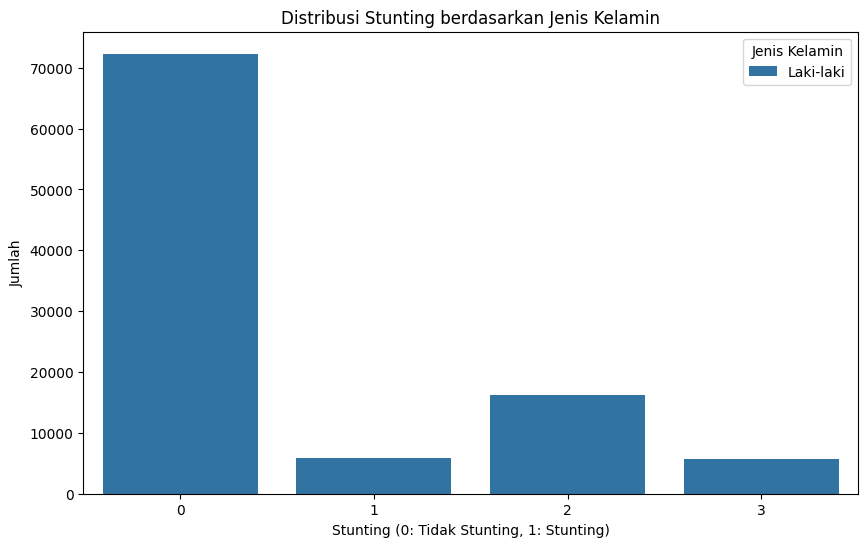

In [42]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='stunting')
plt.title('Distribusi Stunting berdasarkan Jenis Kelamin')
plt.xlabel('Stunting (0: Tidak Stunting, 1: Stunting)')
plt.ylabel('Jumlah')
plt.legend(title='Jenis Kelamin', labels=['Laki-laki', 'Perempuan'])
plt.show()

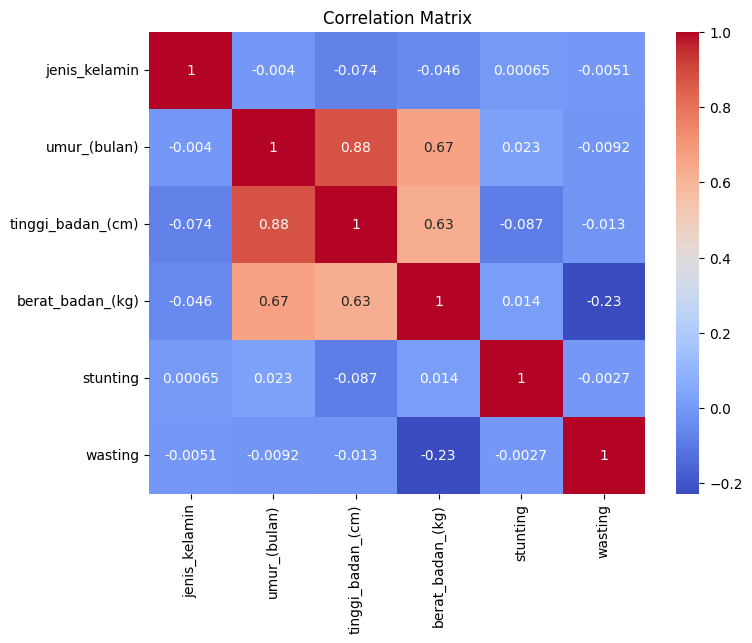

In [43]:
correlation_matrix = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [ ]:
x = df.drop(['stunting', 'wasting'], axis=1)
y = df['stunting']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model  = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)

model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [49]:
y_pred = model.predict(x_test)

print(f"Laporan Klasifikasi : {classification_report(y_test, y_pred)}")
print(f"Akurasi : {accuracy_score(y_test, y_pred) * 100}")

Laporan Klasifikasi :               precision    recall  f1-score   support

           0       0.79      0.96      0.87     14406
           1       0.70      0.03      0.06      1146
           2       0.59      0.41      0.49      3292
           3       0.77      0.11      0.20      1156

    accuracy                           0.77     20000
   macro avg       0.71      0.38      0.40     20000
weighted avg       0.75      0.77      0.72     20000

Akurasi : 76.955


In [53]:
from sklearn.model_selection import GridSearchCV

# Automated Grid Search
param_grid = {'max_depth': list(range(2, 9))}
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,  # Otomatis pakai cross-validation
    scoring='accuracy'
)
grid_search.fit(x_train, y_train)
best_d = grid_search.best_params_['max_depth']

print(f"best max_depth: {best_d}, best accuracy: {grid_search.best_score_ * 100}")

best max_depth: 8, best accuracy: 85.41874999999999
